# Induced Sparsity Experiemnts
This colab shows the code setup we used for the induced sparsity experiments discussed in section 4.1 of our paper.

#Setup
Code for imports and model setup

In [ ]:
import torch, numpy as np
import itertools
import torch.nn as nn, torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# small MLP + data
class TinyMLP(nn.Module):
    """
    Simple MLP for XOR:
    2 inputs → hidden layer (ReLU) → 1 output (sigmoid)
    """
    def __init__(self, in_dim=2, hidden_dim=4):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        return torch.sigmoid(self.fc2(torch.relu(self.fc1(x))))

def make_xor_data():
    """
    Generates XOR dataset:
    """
    X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]], requires_grad=True)
    y = torch.tensor([[0.],[1.],[1.],[0.]], requires_grad=True)
    return X, y

def train_model(model, X, y, l1=0.0, lr=0.05, epochs=5000):
    """
    Trains model using Adam optimizer and binary cross-entropy loss.
    Applies optional l1 regularization and orthogonalization regularization
    """
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for _ in range(epochs):
        opt.zero_grad()
        y_pred = model(X)
        bce = loss_fn(y_pred, y)
        l1_term = model.fc1.weight.abs().sum() * l1
        (bce + l1_term).backward()
        opt.step()
    return model

# Experiment setup

Code for enumerating through and analyzing circuits
- Calculates functional similarity, circuit overlap, causal role of circuits, activation overlap, and activation sparsity
- Enumerates circuits

In [ ]:
def functional_similarity(model, circuit, X, ref_outputs):
    """
    Measures how well a given neuron subset ("circuit") reproduces
    the model's original outputs.

    Process:
    - Creates a mask based off of circuit to keep only select neurons active
    - Uses a hook to zero out anything not part of the circuit
    - Computes model output for only the circuit
    - Calculates Normalized Similarity and Pearson Correlation with reference output

    Args:
      model: MLP model
      circuit: Iterable of neuron indices representing circuit
      X: Input data (XOR dataset)
      ref_outputs: Original model outputs used as reference

    Returns:
      norm_sim : Normalized similarity between circuit output
              and reference output
      corr : Pearson correlation between circuit output and
            reference output
    """
    with torch.no_grad():
        mask = torch.zeros(model.fc1.out_features)
        mask[list(circuit)] = 1.0
        def hook(module, inp, out): return out * mask
        h = model.fc1.register_forward_hook(hook)
        out = model(X)
        h.remove()
        mse = torch.mean((out - ref_outputs)**2).item()
        var_ref = torch.var(ref_outputs).item() + 1e-8
        norm_sim = 1 - mse / var_ref
        corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())
    return max(0, min(1, norm_sim)), corr

def circuit_overlap(circuits):
    """
    Computes mean overlap for circuit

    Args:
      circuits: List of circuits

    Returns:
      mean overlap: Average overlap across all circuit pairs
    """
    overlaps = []
    for i in range(len(circuits)):
        for j in range(i+1, len(circuits)):
            A,B = set(circuits[i]), set(circuits[j])
            overlaps.append(len(A & B)/len(A | B))
    return np.mean(overlaps) if overlaps else 0.0

def evaluate_circuit_causal(model, circuit, X, ref_outputs):
    """
    Evaluates causal role of circuits

    Sufficiency - how well the circuit reproduces output
    Necessity - how much performance drops without circuit

    Args:
      model: MLP model
      circuit: Iterable of neuron indices representing circuit
      X: Input data (XOR dataset)
      ref_outputs: Original model outputs used as reference

    Returns:
        suff_mse: MSE when only the circuit is active
        nec_mse: MSE when the circuit is removed
    """
    with torch.no_grad():
        mask = torch.zeros(model.fc1.out_features)
        mask[list(circuit)] = 1.0
        def hook_suff(m, i, o): return o * mask
        h1 = model.fc1.register_forward_hook(hook_suff)
        suff_out = model(X); h1.remove()
        suff_mse = torch.mean((suff_out - ref_outputs)**2).item()

        def hook_nec(m, i, o): return o * (1 - mask)
        h2 = model.fc1.register_forward_hook(hook_nec)
        nec_out = model(X); h2.remove()
        nec_mse = torch.mean((nec_out - ref_outputs)**2).item()
    return suff_mse, nec_mse

def enumerate_circuits(model, X):
    """
    Enumerates through every possible circuit in model and evaluates output of circuit on dataset X.
    Calculates functional similarity and correlation of each circuit

    Args:
      model: MLP model
      X: Input data (XOR dataset)

    Returns:
      results: pd dataframe table containing each circuit along with its
            functional similarity and correlation to the full model output
    """
    with torch.no_grad():
        ref_outputs = model(X)
    hidden_dim = model.fc1.out_features
    all_circuits = []
    for k in range(1, hidden_dim+1):
        for subset in itertools.combinations(range(hidden_dim), k):
            all_circuits.append(subset)
    results = []
    for c in all_circuits:
        sim, corr = functional_similarity(model, c, X, ref_outputs)
        results.append({"circuit": c, "similarity": sim, "corr": corr})
    return pd.DataFrame(results)

In [ ]:
def activation_overlap(model, circuits, X):
    """
    Determines if different valid circuits are truly distinct mechanisms or just re-parameterizations with the same internal activations

    Compute how similar the internal activations are across different circuits

    Args:
        model: MLP Model
        circuits: List of circuits
        X: Input data (XOR dataset)

    Returns:
      mean overlap: mean overlap of circuit activations
    """
    acts = {}
    with torch.no_grad():
        for c in circuits:
            mask = torch.zeros(model.fc1.out_features)
            mask[list(c)] = 1.0
            def hook(m, i, o): return o * mask
            h = model.fc1.register_forward_hook(hook)
            out = model.fc1(X)
            acts[c] = (out * mask).detach().numpy()
            h.remove()
    # Compute average pairwise cosine similarity between activations
    overlaps = []
    keys = list(acts.keys())
    for i in range(len(keys)):
        for j in range(i+1, len(keys)):
            a, b = acts[keys[i]].flatten(), acts[keys[j]].flatten()
            sim = np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)+1e-8)
            overlaps.append(sim)
    return np.mean(overlaps) if overlaps else 0.0

def activation_sparsity(model, X):
    """
    Measure how sparse the hidden activations are


    Args:
        model: MLP model
        X: Input data (XOR dataset)

    Returns:
        sparsity: fraction of activations that are zero
    """
    with torch.no_grad():
        acts = torch.relu(model.fc1(X))
        return (acts == 0).float().mean().item()

# Running Experiment on Induced Sparsity

In [ ]:
"""
Runs XOR experiments across seeds, hidden sizes, and L1 regularization while gathering data

Data:
- Seed
- Hidden Layer Width (Diameter)
- l1 regularization
- Number of Valid Circuits
- Mean overlap
- Activation overlap
- Activation sparisty
- Mean similarity

"""
X, y = make_xor_data()
records = []

for seed in range(5):
    torch.manual_seed(seed)
    for hidden_dim in [3,4,5,6]:
        for l1 in [0.0, 1e-4, 1e-3]:
            model = TinyMLP(2, hidden_dim)
            model = train_model(model, X, y, l1=l1)
            results = enumerate_circuits(model, X)

            valid = results[results["similarity"] >= 0.9]
            valid_circuits = [tuple(c) for c in valid.circuit]

            mean_overlap = circuit_overlap(valid_circuits)
            act_sparse = activation_sparsity(model, X)
            act_overlap = activation_overlap(model, valid_circuits, X) if len(valid_circuits) > 1 else np.nan

            records.append({
                "seed": seed,
                "hidden_dim": hidden_dim,
                "l1": l1,
                "num_valid": len(valid_circuits),
                "mean_overlap": mean_overlap,
                "activation_overlap": act_overlap,
                "act_sparsity": act_sparse,
                "mean_similarity": valid.similarity.mean()
            })

df = pd.DataFrame(records)
df.head()

/tmp/ipython-input-2765254765.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())
/tmp/ipython-input-2765254765.py:12: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())


,seed,hidden_dim,l1,num_valid,mean_overlap,activation_overlap,act_sparsity,act_entropy,mean_similarity
0,0,3,0.0000,2,0.666667,0.978341,0.833333,0.000000,1.000000
1,0,3,0.0001,7,0.333333,0.400378,0.333333,0.603672,0.997968
2,0,3,0.0010,4,0.500000,0.633854,0.916667,0.000000,1.000000
3,0,4,0.0000,4,0.638889,0.985354,0.750000,0.000065,1.000000
4,0,4,0.0001,4,0.638889,0.736927,0.437500,0.338362,0.963981


# Display Data

Data gathered is shown in the form of a Spearman Correlation chart which is shown in section 4.1 of the paper.

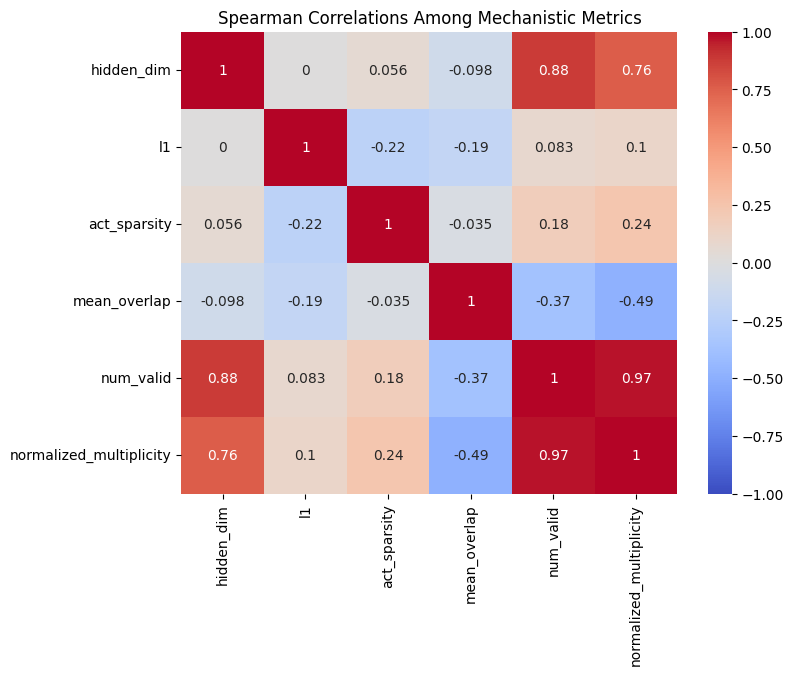

H1_width_vs_multiplicity: rho=0.880, p=0.0000
H2_L1_vs_multiplicity: rho=0.083, p=0.5307
H3_sparsity_vs_multiplicity: rho=0.177, p=0.1763
H4_overlap_vs_multiplicity: rho=-0.374, p=0.0033


In [ ]:
# --- Add normalized multiplicity
df["normalized_multiplicity"] = df["num_valid"] / df["hidden_dim"]

# --- Compute correlation matrix
metrics = ["hidden_dim", "l1", "act_sparsity", "mean_overlap", "num_valid", "normalized_multiplicity"]
corr = df[metrics].corr(method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Spearman Correlations Among Mechanistic Metrics")
plt.show()

# --- Quantify each hypothesis directly
tests = {
    "H1_width_vs_multiplicity": spearmanr(df["hidden_dim"], df["num_valid"]),
    "H2_L1_vs_multiplicity": spearmanr(df["l1"], df["num_valid"]),
    "H3_sparsity_vs_multiplicity": spearmanr(df["act_sparsity"], df["num_valid"]),
    "H4_overlap_vs_multiplicity": spearmanr(df["mean_overlap"], df["num_valid"]),
}
for k, v in tests.items():
    print(f"{k}: rho={v[0]:.3f}, p={v[1]:.4f}")
